# BayesianReal

In [1]:
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
from tests.train_test_split import train_test_split
from src.QDAClassifier import QDAClassifier
from src.NBClassifier import NBClassifier
from src.LDAClassifier import LDAClassifier

In [2]:
data, meta = arff.loadarff('../../data/php8Mz7BG.arff')
data_array = np.array(data.tolist())

X = data_array[:, :-1].astype(float)   
y = (data_array[:, -1]).astype(int) - 1

In [3]:
X.shape

(5404, 5)

In [4]:
y.shape

(5404,)

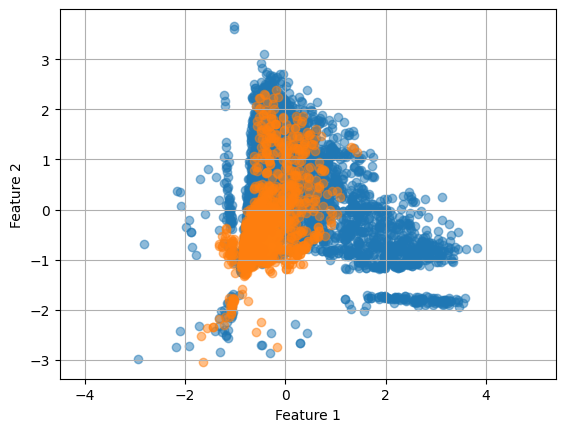

In [5]:
fig = plt.subplot( )
fig.scatter(X[y==0, 0], X[y==0, 1], label='Class 0', alpha=0.5)
fig.scatter(X[y==1, 0], X[y==1, 1], label='Class 1', alpha=0.5)
fig.set_xlabel('Feature 1')
fig.set_ylabel('Feature 2')
fig.axis('equal')
fig.grid()

C:\Users\muric\AppData\Local\Temp\ipykernel_22048\1906272692.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'{int(r*100)}/{int((1-r)*100)}' for r in split_ratios])
C:\Users\muric\AppData\Local\Temp\ipykernel_22048\1906272692.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'{int(r*100)}/{int((1-r)*100)}' for r in split_ratios])
C:\Users\muric\AppData\Local\Temp\ipykernel_22048\1906272692.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'{int(r*100)}/{int((1-r)*100)}' for r in split_ratios])


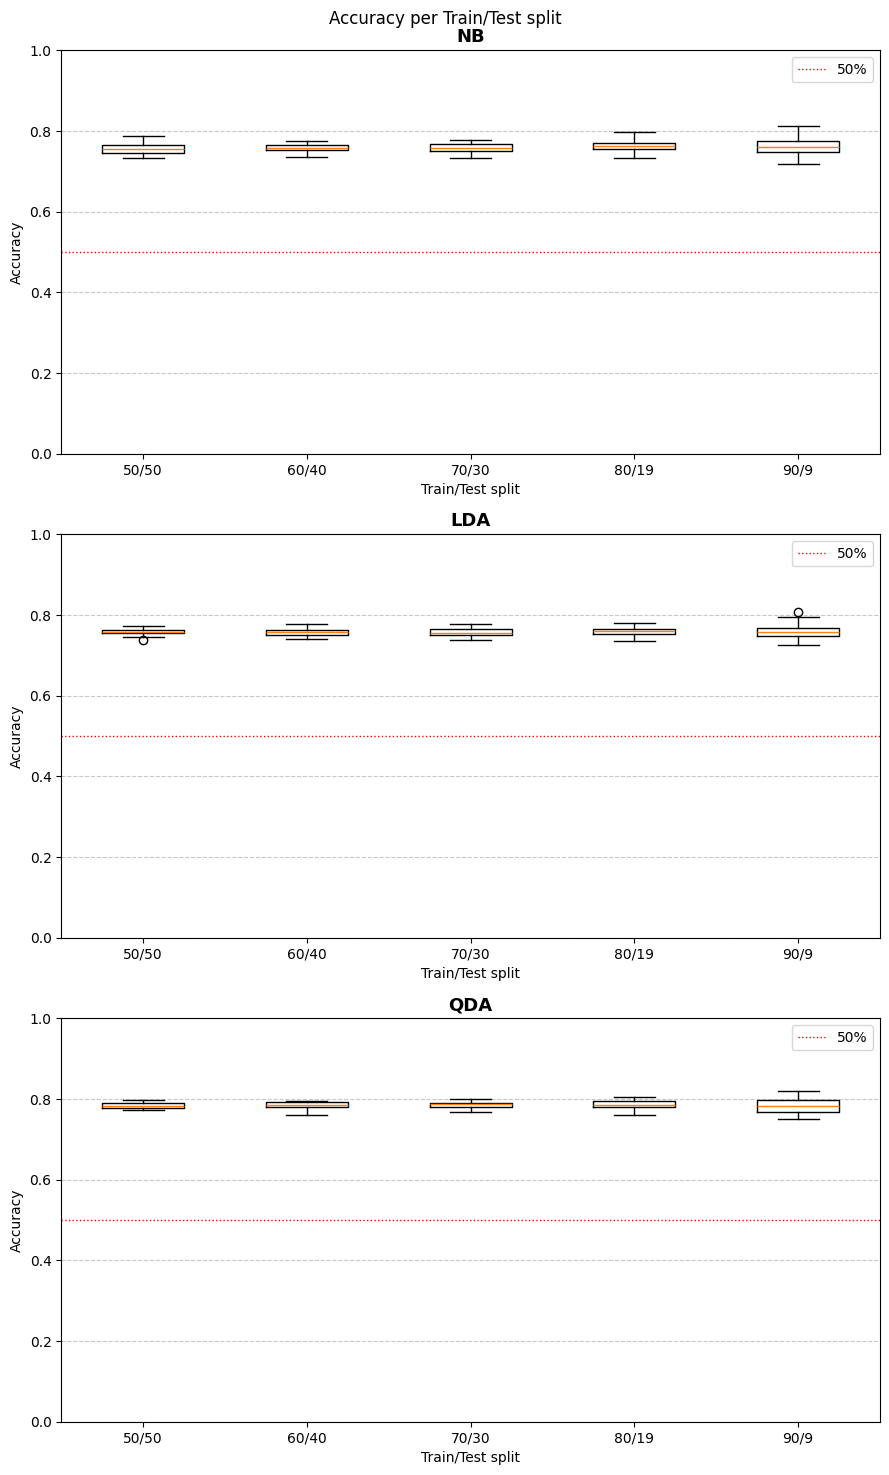

In [6]:
a_values = [0.1, 0.5, 1, 2, 3, 5]
n_repeats = 30
split_ratios = [0.5, 0.6, 0.7, 0.8, 0.9]

results = {
    'NB':  {r: [] for r in split_ratios},
    'LDA': {r: [] for r in split_ratios},
    'QDA': {r: [] for r in split_ratios},
}

for ratio in split_ratios:
    for _ in range(n_repeats):
        X_train, X_test, y_train, y_test = train_test_split(X, y, ratio)
        
        for name, classifier in [('NB',  NBClassifier()),
                                  ('LDA', LDAClassifier()),
                                  ('QDA', QDAClassifier())]:
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
            results[name][ratio].append(np.mean(y_pred == y_test))

fig, axes = plt.subplots(3, 1, figsize=(9, 15))

for ax, name in zip(axes, ['NB', 'LDA', 'QDA']):
    data = [results[name][r] for r in split_ratios]
    ax.boxplot(data, labels=[f'{int(r*100)}/{int((1-r)*100)}' for r in split_ratios])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Train/Test split')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1, label='50%')
    ax.legend()
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Accuracy per Train/Test split')
plt.tight_layout()
plt.show()